# Week 5: Data Manipulation - Class Exercises

We first load the packages necessary for this exercise.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from nycflights13 import flights

---

## Flights in New York City in 2013

In this question, we use the `flights` data set from the `nycflights13` package.

1. Remove cancelled flights (i.e., missing `dep_time`) and compute:

    (a) The number of flights that flew to Houston (with either `IAH` or `HOU` as the flight destination).
    
    (b) For each origin airport, compute the average departure delay. Which airport was the most punctual (with the lowest average departure delay)?
    
    **Hint**: For (a), check out the `subset` parameter in the `pandas` `dropna()` method.

In [12]:
#   Your Code Here
import pandas as pd
from nycflights13 import flights

# 1. remove cancelled flights (missing dep_time)
flights_nc = flights.dropna(subset=['dep_time'])

# (a) number of flights to Houston (IAH or HOU)
houston_count = flights_nc[flights_nc['dest'].isin(['IAH', 'HOU'])].shape[0]
print("Flights to Houston (IAH or HOU):", houston_count)

# (b) average departure delay by origin, and most punctual origin (lowest avg dep_delay)
avg_dep_delay_by_origin = flights_nc.groupby('origin', observed=True)['dep_delay'].mean().reset_index()
print("Average departure delay by origin:")
print(avg_dep_delay_by_origin)

most_punctual = avg_dep_delay_by_origin.loc[avg_dep_delay_by_origin['dep_delay'].idxmin()]
print("Most punctual origin (lowest avg dep_delay):", most_punctual['origin'],
      "with avg dep_delay =", most_punctual['dep_delay'])


Flights to Houston (IAH or HOU): 9193
Average departure delay by origin:
  origin  dep_delay
0    EWR  15.107954
1    JFK  12.112159
2    LGA  10.346876
Most punctual origin (lowest avg dep_delay): LGA with avg dep_delay = 10.3468756464944


*Your Answer*

(a) The number of flights that flew to Houston was **____9193_**.

(b) The most punctual airport was **__LGA**.

2. For this part, we focus on flights that departed from the `JFK` airport and explore the average departure delay by scheduled departure hours:

    (a) Calculate the average departure delay for each scheduled departure hour of the day. Use the column `hour` as the hour of scheduled departure.

    (b) Re-create, as much as you can, the bar chart below to visualize the results.

    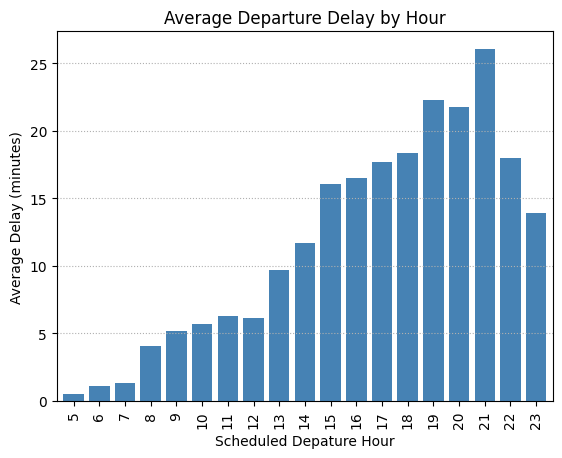
    

In [13]:
#   Your Code Here


# remove cancelled flights
flights_nc = flights.dropna(subset=['dep_time'])

# filter JFK departures
jfk = flights_nc[flights_nc['origin'] == 'JFK']

# (a) average departure delay by scheduled hour
avg_dep_delay_by_hour = (
    jfk.groupby('hour', observed=True)['dep_delay']
       .mean()
       .reset_index()
       .sort_values('hour')
       .rename(columns={'dep_delay': 'avg_dep_delay'})
)

print(avg_dep_delay_by_hour)


    hour  avg_dep_delay
0      5       0.510724
1      6       1.113244
2      7       1.334720
3      8       4.090567
4      9       5.203929
5     10       5.683427
6     11       6.324407
7     12       6.159816
8     13       9.701588
9     14      11.673032
10    15      16.037580
11    16      16.507861
12    17      17.666394
13    18      18.392243
14    19      22.309884
15    20      21.747574
16    21      26.058599
17    22      17.997834
18    23      13.895610


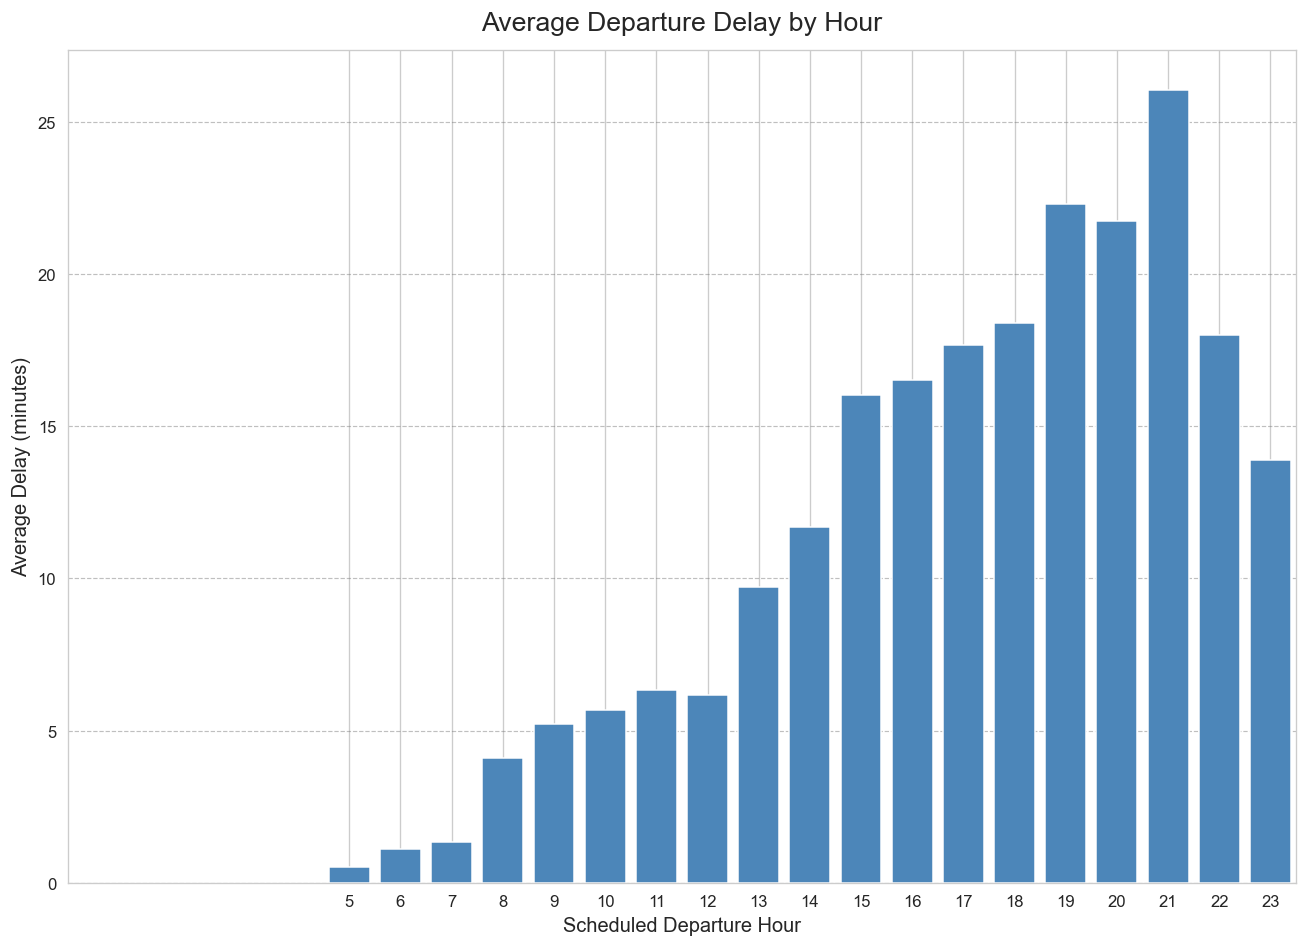

In [14]:

import matplotlib.pyplot as plt
import seaborn as sns


# Data preparation
flights_nc = flights.dropna(subset=['dep_time'])
jfk = flights_nc[flights_nc['origin'] == 'JFK']
avg_dep_delay_by_hour = (
    jfk.groupby('hour', observed=True)['dep_delay']
       .mean()
       .reset_index()
       .sort_values('hour')
       .rename(columns={'dep_delay': 'avg_dep_delay'})
)

# Plot
sns.set_style("whitegrid")
plt.rcParams.update({'figure.dpi': 120})
fig, ax = plt.subplots(figsize=(11, 8))

bars = ax.bar(avg_dep_delay_by_hour['hour'],
              avg_dep_delay_by_hour['avg_dep_delay'],
              color='#4C86B9', edgecolor='white', linewidth=0.6)

# Labels / ticks / title
ax.set_xlabel('Scheduled Departure Hour', fontsize=12)
ax.set_ylabel('Average Delay (minutes)', fontsize=12)
ax.set_title('Average Departure Delay by Hour', fontsize=16, pad=12)
ax.set_xticks(avg_dep_delay_by_hour['hour'])
ax.set_xticklabels(avg_dep_delay_by_hour['hour'], rotation=0)
ax.set_xlim(-0.5, avg_dep_delay_by_hour['hour'].max() + 0.5)

# Horizontal grid lines (dashed, light)
ax.yaxis.grid(True, linestyle='--', linewidth=0.7, color='gray', alpha=0.5)
ax.set_axisbelow(True)

# Add small white separators between bars (visually similar to example)
for bar in bars:
    bar.set_linewidth(0.9)
    bar.set_edgecolor('white')

plt.tight_layout()
plt.show()
